In [1]:
#DOWNLOADING. EXTRACTING AND LOADING CIFAR-10 data

import numpy as np
import pickle
import os
import tarfile
from urllib.request import urlretrieve

# Define constants
CIFAR_URL = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
FILE_NAME = 'cifar-10-python.tar.gz'
EXTRACT_DIR = 'cifar-10-batches-py'
DATA_DIR = './' # Current directory

def download_and_extract(url, filename, extract_dir):
    """Downloads and extracts the CIFAR-10 data archive."""
    if not os.path.exists(filename):
        print(f"Downloading {filename}...")
        urlretrieve(url, filename)
        print("Download complete.")

    if not os.path.exists(extract_dir):
        print(f"Extracting {filename} to {extract_dir}...")
        with tarfile.open(filename, 'r:gz') as tar:
            tar.extractall(path=DATA_DIR)
        print("Extraction complete.")
    else:
        print("Data already downloaded and extracted.")

def unpickle(file):
    """Loads a single pickled batch file and returns a dictionary."""
    with open(file, 'rb') as fo:
        # Use 'bytes' encoding for Python 3 compatibility
        dict_data = pickle.load(fo, encoding='bytes')
    return dict_data

def load_cifar10_data(root_dir):
    """Loads all CIFAR-10 batches into numpy arrays."""
    train_data = []
    train_labels = []

    # Load training batches 1 through 5
    for i in range(1, 6):
        batch_file = os.path.join(root_dir, f'data_batch_{i}')
        batch_dict = unpickle(batch_file)

        # The data is a flat numpy array (10000, 3072)
        images = batch_dict[b'data']
        labels = batch_dict[b'labels']

        # Reshape the images from flat array to (10000, 3, 32, 32) (channels first)
        # and then transpose to (10000, 32, 32, 3) (channels last)
        images = images.reshape((10000, 3, 32, 32)).transpose(0, 2, 3, 1)

        train_data.append(images)
        train_labels.append(labels)

    # Concatenate all training batches
    X_train = np.concatenate(train_data)
    y_train = np.concatenate(train_labels)

    # Load the test batch
    test_file = os.path.join(root_dir, 'test_batch')
    test_dict = unpickle(test_file)
    X_test = test_dict[b'data'].reshape((10000, 3, 32, 32)).transpose(0, 2, 3, 1)
    y_test = np.array(test_dict[b'labels'])

    # Normalize pixel values (optional, but recommended)
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    return X_train, y_train, X_test, y_test

# --- Execution ---
download_and_extract(CIFAR_URL, FILE_NAME, EXTRACT_DIR)
X_train, y_train, X_test, y_test = load_cifar10_data(EXTRACT_DIR)

print(f"\nSuccessfully loaded data shapes:")
print(f"Train images: {X_train.shape}, Train labels: {y_train.shape}")
print(f"Test images: {X_test.shape}, Test labels: {y_test.shape}")


Download complete.
Extracting cifar-10-python.tar.gz to cifar-10-batches-py...


/tmp/ipython-input-1430819841.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=DATA_DIR)


Extraction complete.

Successfully loaded data shapes:
Train images: (50000, 32, 32, 3), Train labels: (50000,)
Test images: (10000, 32, 32, 3), Test labels: (10000,)


**1.1 scikit-learn**

• Use MLPClassifier from sklearn.neural_network

• Implement at least one network architecture (shallow, deep, or wide)

In [2]:
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import time


# Normalize pixel values and reshape images for MLP input
# Normalization already done in my script
# We only need to flatten them now:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

print(f"Data shapes: {X_train_flat.shape}, {y_train_flat.shape}, {X_test_flat.shape}, {y_test_flat.shape}")

# Defining a shallow network: 2 hidden layers with 256 neurons each
mlp = MLPClassifier(hidden_layer_sizes=(256, 256), max_iter=50, alpha=1e-4,
                    solver='adam', verbose=1, random_state=1,
                    learning_rate_init=.001)

start_time = time.time()
mlp.fit(X_train_flat, y_train_flat)
end_time = time.time()

print(f"\nTraining time: {end_time - start_time:.2f} seconds")
y_pred = mlp.predict(X_test_flat)
accuracy = accuracy_score(y_test_flat, y_pred)
print(f"Test accuracy: {accuracy:.4f}")



Data shapes: (50000, 3072), (50000,), (10000, 3072), (10000,)
Iteration 1, loss = 1.90177559
Iteration 2, loss = 1.68937763
Iteration 3, loss = 1.60390594
Iteration 4, loss = 1.53868633
Iteration 5, loss = 1.50617700
Iteration 6, loss = 1.46789709
Iteration 7, loss = 1.42911319
Iteration 8, loss = 1.42088542
Iteration 9, loss = 1.38862857
Iteration 10, loss = 1.37784692
Iteration 11, loss = 1.35352260
Iteration 12, loss = 1.32982258
Iteration 13, loss = 1.30994562
Iteration 14, loss = 1.29344420
Iteration 15, loss = 1.27530053
Iteration 16, loss = 1.26285231
Iteration 17, loss = 1.24147422
Iteration 18, loss = 1.23423290
Iteration 19, loss = 1.21129142
Iteration 20, loss = 1.19002105
Iteration 21, loss = 1.18901726
Iteration 22, loss = 1.17526298
Iteration 23, loss = 1.15972756
Iteration 24, loss = 1.14500803
Iteration 25, loss = 1.12675840
Iteration 26, loss = 1.12205809
Iteration 27, loss = 1.11162884
Iteration 28, loss = 1.10155587
Iteration 29, loss = 1.08970021
Iteration 30, loss 

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Test accuracy: 0.5118


This method took too long. Implementing early stop and PCA to reduce complexity and speedup traning.

In [3]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import time

# Flatten image data
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

print(f"Original data shapes: {X_train_flat.shape}, {X_test_flat.shape}")

# Apply PCA to reduce dimensionality (e.g., to 100 components)
pca = PCA(n_components=100, random_state=1)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)

print(f"PCA-reduced shapes: {X_train_pca.shape}, {X_test_pca.shape}")

# Split training data for early stopping
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_pca, y_train_flat, test_size=0.1, random_state=1
)

# Define MLP with early stopping
mlp = MLPClassifier(hidden_layer_sizes=(256, 256), max_iter=200, alpha=1e-4,
                    solver='adam', verbose=1, random_state=1,
                    learning_rate_init=0.001, early_stopping=True,
                    validation_fraction=0.1, n_iter_no_change=10)

start_time = time.time()
mlp.fit(X_train_sub, y_train_sub)
end_time = time.time()

print(f"\nTraining time: {end_time - start_time:.2f} seconds")
y_pred = mlp.predict(X_test_pca)
accuracy = accuracy_score(y_test_flat, y_pred)
print(f"Test accuracy: {accuracy:.4f}")

Original data shapes: (50000, 3072), (10000, 3072)
PCA-reduced shapes: (50000, 100), (10000, 100)
Iteration 1, loss = 1.69324589
Validation score: 0.461778
Iteration 2, loss = 1.44204965
Validation score: 0.493778
Iteration 3, loss = 1.31891518
Validation score: 0.515333
Iteration 4, loss = 1.22852454
Validation score: 0.528889
Iteration 5, loss = 1.15222176
Validation score: 0.538222
Iteration 6, loss = 1.08531076
Validation score: 0.533111
Iteration 7, loss = 1.02654116
Validation score: 0.540667
Iteration 8, loss = 0.97114951
Validation score: 0.549333
Iteration 9, loss = 0.91785556
Validation score: 0.553111
Iteration 10, loss = 0.86731832
Validation score: 0.544000
Iteration 11, loss = 0.82107591
Validation score: 0.543556
Iteration 12, loss = 0.78175945
Validation score: 0.551333
Iteration 13, loss = 0.73844399
Validation score: 0.544444
Iteration 14, loss = 0.69437009
Validation score: 0.542667
Iteration 15, loss = 0.66213331
Validation score: 0.538889
Iteration 16, loss = 0.623

Traning time decreased significantly. Now only approx 29 seconds. Test accruacy improved from 51% to 54%. But MLO is still limited for the image data in CIFAR-10.

**1.2 TensorFlow/Keras**  

• Implement three architectures: shallow, deep, and wide networks

• Use appropriate activation functions, optimizers, and loss functions

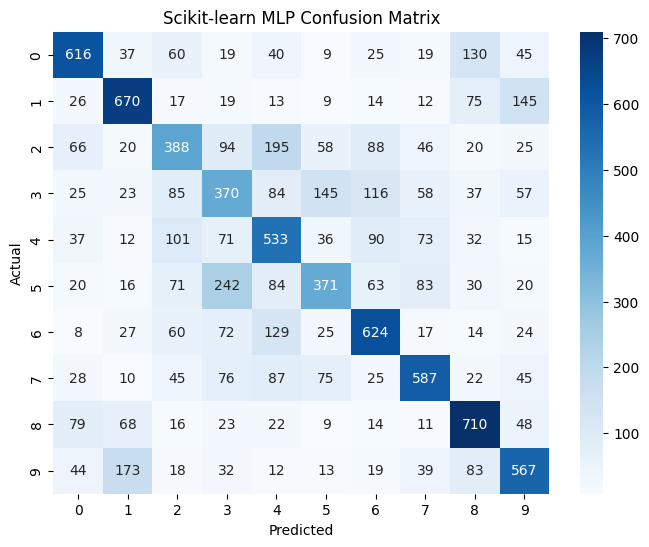

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test_flat, y_pred)

# Plot nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Scikit-learn MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Confusion Matrix Results:

- Class 1 (automobile): 670 very stronge correct predictions, few misclassifications

- Class 8 (ship):  710 correct, almost no confusion.

- Class 2 (bird) & Class 5 (dog): Lots of confusion with other classes.

- Class 3 (cat) and Class 4(deer):Moderate performance, but confused with similar-looking classes.





In [5]:
# --- Keras Model Training with Early Stopping ---
import tensorflow as tf
from tensorflow.keras import layers, models, losses
from tensorflow.keras.callbacks import EarlyStopping
import time

def create_model(architecture_type):
    model = models.Sequential()
    model.add(layers.Flatten(input_shape=(32, 32, 3))) # Flattens image to 1D vector

    if architecture_type == 'shallow':
        model.add(layers.Dense(256, activation='relu'))
        model.add(layers.Dense(256, activation='relu'))
    elif architecture_type == 'deep':
        for _ in range(5):
            model.add(layers.Dense(64, activation='relu'))
    elif architecture_type == 'wide':
        model.add(layers.Dense(1024, activation='relu'))
        model.add(layers.Dense(1024, activation='relu'))

    model.add(layers.Dense(10, activation='softmax'))
    return model

print("\n--- Training Shallow Keras Model with Early Stopping ---")
current_model = create_model('shallow')
current_model.compile(
    optimizer='adam',
    loss=losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

start_time = time.time()
history = current_model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=2
)
end_time = time.time()

test_loss, test_acc = current_model.evaluate(X_test, y_test, verbose=2)
print(f"\nTraining time: {end_time - start_time:.2f} seconds")
print(f"Test accuracy: {test_acc:.4f}")


--- Training Shallow Keras Model with Early Stopping ---
Epoch 1/50
1563/1563 - 22s - 14ms/step - accuracy: 0.3336 - loss: 1.8433 - val_accuracy: 0.3993 - val_loss: 1.6733
Epoch 2/50
1563/1563 - 20s - 13ms/step - accuracy: 0.4007 - loss: 1.6666 - val_accuracy: 0.4176 - val_loss: 1.6233
Epoch 3/50
1563/1563 - 20s - 13ms/step - accuracy: 0.4283 - loss: 1.5952 - val_accuracy: 0.4384 - val_loss: 1.5633
Epoch 4/50
1563/1563 - 20s - 13ms/step - accuracy: 0.4432 - loss: 1.5540 - val_accuracy: 0.4544 - val_loss: 1.5293
Epoch 5/50
1563/1563 - 20s - 13ms/step - accuracy: 0.4520 - loss: 1.5239 - val_accuracy: 0.4492 - val_loss: 1.5379
Epoch 6/50
1563/1563 - 20s - 13ms/step - accuracy: 0.4644 - loss: 1.4928 - val_accuracy: 0.4529 - val_loss: 1.5275
Epoch 7/50
1563/1563 - 20s - 13ms/step - accuracy: 0.4734 - loss: 1.4711 - val_accuracy: 0.4481 - val_loss: 1.5461
Epoch 8/50
1563/1563 - 19s - 12ms/step - accuracy: 0.4825 - loss: 1.4527 - val_accuracy: 0.4650 - val_loss: 1.5071
Epoch 9/50
1563/1563 -

The Keras Model test accuracy shows 48.87% and it took approce 6 minutes.
The MLP is lfateen the image inot a 1 D vector and damaging the 2 D spaatioal relationshipos between the pixels. Therefore, causing loss of spatial information. It is trating each pixel independently and missing patterns.

**1.3 PyTorch**

• Implement all three architectures: shallow, deep, and wide networks

In [8]:
#PyTorch ShallowNet

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import time

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load and normalize CIFAR-10 data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

# --- Define Architectures ---
class ShallowNet(nn.Module):
    def __init__(self):
        super(ShallowNet, self).__init__()
        self.fc1 = nn.Linear(32*32*3, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(-1, 32*32*3)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class DeepNet(nn.Module):
    def __init__(self):
        super(DeepNet, self).__init__()
        self.fc1 = nn.Linear(32*32*3, 128)
        self.hidden = nn.ModuleList([nn.Linear(128, 128) for _ in range(5)])  # 5 hidden layers
        self.fc_out = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 32*32*3)
        x = torch.relu(self.fc1(x))
        for layer in self.hidden:
            x = torch.relu(layer(x))
        x = self.fc_out(x)
        return x

class WideNet(nn.Module):
    def __init__(self):
        super(WideNet, self).__init__()
        self.fc1 = nn.Linear(32*32*3, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, 10)

    def forward(self, x):
        x = x.view(-1, 32*32*3)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# --- Early Stopping Parameters ---
early_stop_patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0

# --- Training Function with Early Stopping ---
def train_model(model, criterion, optimizer, num_epochs=50):
    model.to(device)
    start_time = time.time()
    best_model_state = None
    global best_val_loss, epochs_no_improve

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(trainloader)

        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(testloader)

        print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # --- Early Stopping Check ---
        if avg_val_loss < best_val_loss - 1e-4:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_state = model.state_dict()
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= early_stop_patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    end_time = time.time()
    print(f"Training time: {end_time - start_time:.2f} seconds")

    # Restore best model weights
    if best_model_state:
        model.load_state_dict(best_model_state)

    return model

# --- Evaluation Function ---
def test_model(model):
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Test accuracy: {100 * correct / total:.2f} %")

# --- Train and Evaluate ---
print("\n--- Training Shallow PyTorch Model with Early Stopping ---")
current_net = ShallowNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(current_net.parameters(), lr=0.001)

current_net = train_model(current_net, criterion, optimizer)
test_model(current_net)

Using device: cpu

--- Training Shallow PyTorch Model with Early Stopping ---
Epoch 1, Train Loss: 1.6265, Val Loss: 1.5118
Epoch 2, Train Loss: 1.4252, Val Loss: 1.4165
Epoch 3, Train Loss: 1.3137, Val Loss: 1.3791
Epoch 4, Train Loss: 1.2263, Val Loss: 1.3582
Epoch 5, Train Loss: 1.1491, Val Loss: 1.3789
Epoch 6, Train Loss: 1.0777, Val Loss: 1.3808
Epoch 7, Train Loss: 1.0079, Val Loss: 1.4205
Epoch 8, Train Loss: 0.9395, Val Loss: 1.4680
Epoch 9, Train Loss: 0.8761, Val Loss: 1.4607
Early stopping triggered at epoch 9
Training time: 267.74 seconds
Test accuracy: 53.19 %


Model: Shallow MLP with two hidden layers (256 neurons each)
Training Time: 232.96 seconds
Early Stopping: Triggered at epoch 9 due to plateauing validation loss
Test Accuracy: 52.77

In [10]:
#PyTorch DeepNet

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import time

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load and normalize CIFAR-10 data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

# --- Define Architectures ---
class ShallowNet(nn.Module):
    def __init__(self):
        super(ShallowNet, self).__init__()
        self.fc1 = nn.Linear(32*32*3, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(-1, 32*32*3)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class DeepNet(nn.Module):
    def __init__(self):
        super(DeepNet, self).__init__()
        self.fc1 = nn.Linear(32*32*3, 128)
        self.hidden = nn.ModuleList([nn.Linear(128, 128) for _ in range(5)])  # 5 hidden layers
        self.fc_out = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 32*32*3)
        x = torch.relu(self.fc1(x))
        for layer in self.hidden:
            x = torch.relu(layer(x))
        x = self.fc_out(x)
        return x

class WideNet(nn.Module):
    def __init__(self):
        super(WideNet, self).__init__()
        self.fc1 = nn.Linear(32*32*3, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, 10)

    def forward(self, x):
        x = x.view(-1, 32*32*3)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# --- Early Stopping Parameters ---
early_stop_patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0

# --- Training Function with Early Stopping ---
def train_model(model, criterion, optimizer, num_epochs=50):
    model.to(device)
    start_time = time.time()
    best_model_state = None
    global best_val_loss, epochs_no_improve

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(trainloader)

        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(testloader)

        print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # --- Early Stopping Check ---
        if avg_val_loss < best_val_loss - 1e-4:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_state = model.state_dict()
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= early_stop_patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    end_time = time.time()
    print(f"Training time: {end_time - start_time:.2f} seconds")

    # Restore best model weights
    if best_model_state:
        model.load_state_dict(best_model_state)

    return model

# --- Evaluation Function ---
def test_model(model):
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Test accuracy: {100 * correct / total:.2f} %")

# --- Train and Evaluate ---
print("\n--- Training Deep PyTorch Model with Early Stopping ---")
current_net = DeepNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(current_net.parameters(), lr=0.001)

current_net = train_model(current_net, criterion, optimizer)
test_model(current_net)



Using device: cpu

--- Training Deep PyTorch Model with Early Stopping ---
Epoch 1, Train Loss: 1.7647, Val Loss: 1.5985
Epoch 2, Train Loss: 1.5233, Val Loss: 1.4998
Epoch 3, Train Loss: 1.4054, Val Loss: 1.4352
Epoch 4, Train Loss: 1.3250, Val Loss: 1.4010
Epoch 5, Train Loss: 1.2546, Val Loss: 1.3908
Epoch 6, Train Loss: 1.1953, Val Loss: 1.3769
Epoch 7, Train Loss: 1.1473, Val Loss: 1.3820
Epoch 8, Train Loss: 1.0980, Val Loss: 1.3676
Epoch 9, Train Loss: 1.0551, Val Loss: 1.3753
Epoch 10, Train Loss: 1.0129, Val Loss: 1.3845
Epoch 11, Train Loss: 0.9759, Val Loss: 1.4038
Epoch 12, Train Loss: 0.9375, Val Loss: 1.4391
Epoch 13, Train Loss: 0.9026, Val Loss: 1.4780
Early stopping triggered at epoch 13
Training time: 318.09 seconds
Test accuracy: 52.38 %


PyTorch DeepNet Results:

Test Accuracy: 52.38%

Epochs Ran: 13(early stopped)

Traning time: Approx. 5 minutes

In [12]:
#PyTorch WideNet

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import time

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load and normalize CIFAR-10 data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

# --- Define Architectures ---
class ShallowNet(nn.Module):
    def __init__(self):
        super(ShallowNet, self).__init__()
        self.fc1 = nn.Linear(32*32*3, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(-1, 32*32*3)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class DeepNet(nn.Module):
    def __init__(self):
        super(DeepNet, self).__init__()
        self.fc1 = nn.Linear(32*32*3, 128)
        self.hidden = nn.ModuleList([nn.Linear(128, 128) for _ in range(5)])  # 5 hidden layers
        self.fc_out = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 32*32*3)
        x = torch.relu(self.fc1(x))
        for layer in self.hidden:
            x = torch.relu(layer(x))
        x = self.fc_out(x)
        return x

class WideNet(nn.Module):
    def __init__(self):
        super(WideNet, self).__init__()
        self.fc1 = nn.Linear(32*32*3, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, 10)

    def forward(self, x):
        x = x.view(-1, 32*32*3)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# --- Early Stopping Parameters ---
early_stop_patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0

# --- Training Function with Early Stopping ---
def train_model(model, criterion, optimizer, num_epochs=50):
    model.to(device)
    start_time = time.time()
    best_model_state = None
    global best_val_loss, epochs_no_improve

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(trainloader)

        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(testloader)

        print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # --- Early Stopping Check ---
        if avg_val_loss < best_val_loss - 1e-4:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_state = model.state_dict()
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= early_stop_patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    end_time = time.time()
    print(f"Training time: {end_time - start_time:.2f} seconds")

    # Restore best model weights
    if best_model_state:
        model.load_state_dict(best_model_state)

    return model

# --- Evaluation Function ---
def test_model(model):
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Test accuracy: {100 * correct / total:.2f} %")

# --- Train and Evaluate ---
print("\n--- Training Wide PyTorch Model with Early Stopping ---")
current_net = WideNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(current_net.parameters(), lr=0.001)

current_net = train_model(current_net, criterion, optimizer)
test_model(current_net)



Using device: cpu

--- Training Wide PyTorch Model with Early Stopping ---
Epoch 1, Train Loss: 1.6531, Val Loss: 1.5078
Epoch 2, Train Loss: 1.4460, Val Loss: 1.4590
Epoch 3, Train Loss: 1.3323, Val Loss: 1.4126
Epoch 4, Train Loss: 1.2361, Val Loss: 1.4034
Epoch 5, Train Loss: 1.1463, Val Loss: 1.4164
Epoch 6, Train Loss: 1.0622, Val Loss: 1.4081
Epoch 7, Train Loss: 0.9795, Val Loss: 1.4706
Epoch 8, Train Loss: 0.8958, Val Loss: 1.5925
Epoch 9, Train Loss: 0.8169, Val Loss: 1.5627
Early stopping triggered at epoch 9
Training time: 582.73 seconds
Test accuracy: 52.71 %


Pytorch WideNet Results

Accuracy: 52.71%
Epochs Run: 9 (early stopped)
Tranining time: Approx 10 minutes

Notes: Accuracy stayed at 52%, suggesting that limitation of MLPSs on image data like CIFAR-10

Plot Training & Validation Loss Curves (PyTorch)

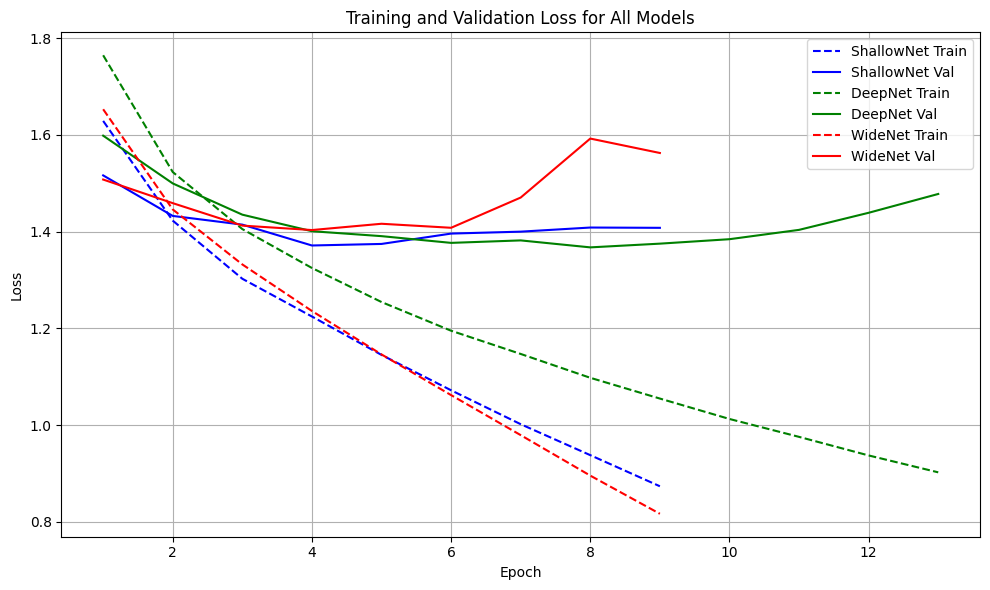

In [16]:
import matplotlib.pyplot as plt

# --- Loss Data ---
shallow_train = [1.6290, 1.4229, 1.3027, 1.2247, 1.1453, 1.0722, 1.0021, 0.9381, 0.8738]
shallow_val   = [1.5164, 1.4326, 1.4146, 1.3715, 1.3747, 1.3961, 1.4001, 1.4086, 1.4080]

deep_train = [1.7647, 1.5233, 1.4054, 1.3250, 1.2546, 1.1953, 1.1473, 1.0980, 1.0551, 1.0129, 0.9759, 0.9375, 0.9026]
deep_val   = [1.5985, 1.4998, 1.4352, 1.4010, 1.3908, 1.3769, 1.3820, 1.3676, 1.3753, 1.3845, 1.4038, 1.4391, 1.4780]

wide_train = [1.6531, 1.4460, 1.3323, 1.2361, 1.1463, 1.0622, 0.9795, 0.8958, 0.8169]
wide_val   = [1.5078, 1.4590, 1.4126, 1.4034, 1.4164, 1.4081, 1.4706, 1.5925, 1.5627]

# --- Plot ---
plt.figure(figsize=(10, 6))

# ShallowNet
plt.plot(range(1, len(shallow_train)+1), shallow_train, label='ShallowNet Train', linestyle='--', color='blue')
plt.plot(range(1, len(shallow_val)+1), shallow_val, label='ShallowNet Val', linestyle='-', color='blue')

# DeepNet
plt.plot(range(1, len(deep_train)+1), deep_train, label='DeepNet Train', linestyle='--', color='green')
plt.plot(range(1, len(deep_val)+1), deep_val, label='DeepNet Val', linestyle='-', color='green')

# WideNet
plt.plot(range(1, len(wide_train)+1), wide_train, label='WideNet Train', linestyle='--', color='red')
plt.plot(range(1, len(wide_val)+1), wide_val, label='WideNet Val', linestyle='-', color='red')

plt.title('Training and Validation Loss for All Models')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Plot Training & Validation Loss Curves Results:

ShallowNet

-Train loss steadily decreases.

-Validation loss plateaus early and stays flat.

Conclusion: It learns quickly but lacks capacity to model complex patterns.Proven to be efficient but underfits.

DeepNet

-Train loss drops gradually.

-Validation loss improves until ~epoch 8, then rises.

Conclusion : Is better at generalizing  than ShallowNet but starts to overfit after a point. Balanced depth helps, but early stopping is key.

WideNet
- Train loss drops fastest.

- Validation loss rises sharply after epoch 6.

- Conclusion : It memorizes training data quickly but fails to generalize.




Trade-Offs: Complexity vs. Time vs. Performance

The experiments we have performed showed that the size and shape of a neural network directly affect how fast it trains and how well it performs. The ShallowNet model trained quickly and had stable loss values, but it didn’t learn enough — its accuracy stayed low because it was too simple. DeepNet, which had more layers but fewer neurons per layer, took longer to train but did a better job of learning patterns without overfitting too quickly. WideNet, with very large layers, learned fast but started to memorize the training data We observed that its validation loss increased even as training loss dropped, which is a sign of overfitting. These results show that deeper models can provide a better balance between learning and generalizing, while wider models need extra care to avoid learning noise.  So we are reminded that when choosing a model, it is important to look beyond accuracy and consider how efficiently it learns and how well it handles new data.


Framework Comparison: Intuition & Efficiency

When we used scikit-learn, Keras, and PyTorch it helped to understand the strengths of each tool. Scikit-learn was the easiest to get started with and great for testing simple models quickly. However, it is not powerful enough for working with image data or building deeper networks.

Keras was the most user-friendly. It has a clean design and built-in features like early stopping made it fast and efficient for trying out ideas.

PyTorch took more code to set up, but gave us full control over how models were built and trained, which was helpful for learning and debugging.

Overall, Keras was best for quick experiments, PyTorch was best for flexibility and insight, and scikit-learn worked well for basic models. Using all three gave us a well-rounded view of how different frameworks handle neural networks.
